# Putting it all Together:

**In this notebook, I walk through an example putting all the pieces we've worked on so far togther in a commented example:**

1. Reading in and assembling coordinates from the headers
2. Interpolating HMI data onto the assembled DKIST coordinates 
3. Writing a loss function to minimize the difference between HMI data and DKIST data
4. Using scipy's minimization methods to find the best position of the coordinates

In [1]:
import scipy.optimize as opt

import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt

from sunpy.net import Fido, attrs as a
import dkist
from sunpy import map as map

import os

from astropy.time import Time
import astropy.units as u

from scipy import interpolate as interp

In [ ]:
def load_hmi_data(time):
    """
    This function loads in the HMI data from the NSO archive for a given time. It returns the x and y coordinates of the HMI data, as well as the intensity data.
    
    Parameters:
    -----------
    time (astropy.time.Time): the time for which to load the HMI data.

    Returns:
    --------
    hmix (numpy.ndarray): the x coordinates of the HMI data.
    hmiy (numpy.ndarray): the y coordinates of the HMI data.
    hmi_data (numpy.ndarray): the intensity data of the HMI data.
    """

    # Seach FIDO for the HMI data for some given time, +/- 1 minute. In the real thing, we'll have to read in the HMI data for all the slits and read in each
    results = Fido.search(a.Instrument.hmi, a.Physobs('intensity'), a.Time(time - 1*u.minute, time + 1*u.minute))
    print(results)

    # Fetch the HMI data from the NSO data server.
    hmi_files = Fido.fetch(results, site="NSO")

    # read in the first HMI file using scipy.map to extract the coordinates and data.
    hmi = map.Map(hmi_files[0])

    # read in the x and y coordinates as seperate arrays.
    hmix = map.all_coordinates_from_map(hmi).Tx
    hmiy = map.all_coordinates_from_map(hmi).Ty
    
    # read in the intensity data as a 2D array. 
    hmi_data = hmi.data

    return hmix, hmiy, hmi_data

def construct_dkist_coords(all_fits, path_to_local_fits):
    """
    This function constructs the default coordinates of the DKIST data from the fits files. 
    It returns a 3D array of the coordinates, with shape (nx, ny, 2), where nx is the number of slits, ny is the number of pixels along the slit, and 2 is for the x and y coordinates.
    
    Parameters:
    -----------
    all_fits (list): a list of the fits files to load in.
    path_to_local_fits (str): the path to the local fits files.

    Returns:
    --------
    coords_new (numpy.ndarray): a 3D array of the coordinates, with shape (nx, ny, 2), where nx is the number of slits, ny is the number of pixels along the slit, and 2 is for the x and y coordinates.
    """
    # open the first fits file to load in the header keywords that don't change across the files (like the cdelt and pc values, which are needed to calculate the coordinates)
    test_header = fits.open(path_to_local_fits + all_fits[0])[1].header

    crval1 = test_header['CRVAL1']
    crval3 = test_header['CRVAL3']

    crpix1 = test_header['CRPIX1']
    crpix3 = test_header['CRPIX3']

    cdelt1 = test_header['CDELT1']
    cdelt3 = test_header['CDELT3']

    pc1_1 = test_header['PC1_1']
    pc1_3 = test_header['PC1_3']
    pc3_1 = test_header['PC3_1']
    pc3_3 = test_header['PC3_3']

    nx = test_header['DNAXIS3']
    ny = test_header['DNAXIS1']

    # initialize an empty array to fill with the coordinates. the shape is (nx, ny, 2) because we have nx by ny pixels and each pixel has an x and y coordinate.
    coords_new = np.zeros((nx, ny, 2))


    # loop through each fits file, extract the relevant header keywords, and calculate the coordinates for each pixel in that slit. then fill the coords_new array with those coordinates.
    for i, slit_i in enumerate(all_fits[:nx]):
        # open each fits file to load in the header keywords that change across the files.
        # I later change this to not open each fits file in this function - see below.
        temp_header = fits.open(path_to_local_fits + slit_i)[1].header

        crval1 = temp_header['CRVAL1']
        crval3 = temp_header['CRVAL3']

        crpix1 = temp_header['CRPIX1']
        crpix3 = temp_header['CRPIX3']

        # y-index of the position of the pixel ALONG the slit (i.e. 1 to ny). This is used to calculate the coordinates of each pixel along the slit.
        indices = np.linspace(1, ny, ny, dtype = int)

        # calculate the coordinates of each pixel along the slit using the header keywords and the y-index. 
        # This formula is the linear transformation-matrix form of the coordinate assembly.
        slit_coords_x = crval3 + cdelt3 * (pc3_3 * (i - crpix3) + pc3_1 * (indices - crpix1))
        slit_coords_y = crval1 + cdelt1 * (pc1_3 * (i - crpix3) + pc1_1 * (indices - crpix1))

        # save each pixel's coordinates into x and y indices of the the coords_new array. 
        coords_new[i, :, 0] = slit_coords_x
        coords_new[i, :, 1] = slit_coords_y

    return coords_new

def identify_relevant_hmi_data(coords_new, hmix, hmiy, hmi_data, delta = 20):
    """
    This function identifies the relevant HMI data that overlaps with the DKIST data, with a buffer of delta arcseconds on each side. 
    It returns the x and y coordinates of the relevant HMI data, as well as the intensity data.
    
    Parameters:
    -----------
    coords_new (numpy.ndarray): a 3D array of the coordinates of the DKIST data, with shape (nx, ny, 2), where nx is the number of slits, ny is the number of pixels along the slit, and 2 is for the x and y coordinates.
    hmix (numpy.ndarray): the x coordinates of the HMI data.
    hmiy (numpy.ndarray): the y coordinates of the HMI data.
    hmi_data (numpy.ndarray): the intensity data of the HMI data.
    delta (float): the buffer in arcseconds to add to the DKIST data when identifying the relevant HMI data. Default is 20 arcseconds.
    
    Returns:
    --------
    relavent_hmix (numpy.ndarray): the x coordinates of the relevant HMI data.
    relavent_hmiy (numpy.ndarray): the y coordinates of the relevant HMI data.
    relavent_hmi_data (numpy.ndarray): the intensity data of the relevant HMI data.
    """
    # construct a box of HMI coordinates and data around the DKIST data, with a buffer of delta arcseconds on each side. 
    relavent_hmix_indices = sorted([np.argmin(np.abs(np.min(coords_new[:, :, 0]) - delta - hmix[0, :].value)), np.argmin(np.abs(np.max(coords_new[:, :, 0]) + delta - hmix[0, :].value))])
    relavent_hmiy_indices = sorted([np.argmin(np.abs(np.min(coords_new[:, :, 1]) - delta - hmiy[:, 0].value)), np.argmin(np.abs(np.max(coords_new[:, :, 1]) + delta - hmiy[:, 0].value))])

    # crop the x and y coordinates of the HMI data to the relevant coordinates. Note that the HMI data is transposed because the x and y coordinates are in the opposite order of the data array.
    relavent_hmix = hmix[0, relavent_hmix_indices[0]:relavent_hmix_indices[1]].value
    relavent_hmiy = hmiy[relavent_hmiy_indices[0]:relavent_hmiy_indices[1], 0].value

    # crop the HMI data to the relevant coordinates. Note that the HMI data is transposed because the x and y coordinates are in the opposite order of the data array.
    relavent_hmi_data= hmi_data.T[relavent_hmix_indices[0]:relavent_hmix_indices[1], relavent_hmiy_indices[0]:relavent_hmiy_indices[1]].T

    return relavent_hmix, relavent_hmiy, relavent_hmi_data

def interpolate_hmi_to_coords(relavent_hmix, relavent_hmiy, relavent_hmi_data, coords_new):
    """
    This function interpolates the relevant HMI data onto the DKIST coordinates. It returns a 2D array of the interpolated HMI data, with shape (nx, ny), where nx is the number of slits and ny is the number of pixels along the slit.
    
    Parameters:
    -----------
    relavent_hmix (numpy.ndarray): the x coordinates of the relevant HMI data.
    relavent_hmiy (numpy.ndarray): the y coordinates of the relevant HMI data.
    relavent_hmi_data (numpy.ndarray): the intensity data of the relevant HMI data.
    coords_new (numpy.ndarray): a 3D array of the coordinates of the DKIST data, with shape (nx, ny, 2), where nx is the number of slits, ny is the number of pixels along the slit, and 2 is for the x and y coordinates.
    
    Returns:
    --------
    Z_fine (numpy.ndarray): a 2D array of the interpolated HMI data, with shape (nx, ny), where nx is the number of slits and ny is the number of pixels along the slit.
    """
    # an example of one way to interpolate the HMI data onto the DKIST coordinates. 
    # I don't know if this is the final method we'll use but it is a working example.
    
    # set up the interpolator:
    grid_interpolator = interp.RegularGridInterpolator(
        (relavent_hmiy, relavent_hmix),
        relavent_hmi_data, 
        method='cubic',
        bounds_error=False, 
        fill_value=np.nan
    )

    # perform the interpolation onto whatever coordiantes you give it. Here, we give it the DKIST coordinates.
    Z_fine = grid_interpolator((coords_new[:, :, 1], coords_new[:, :, 0]))

    return Z_fine



def read_fits_headers(all_fits, path_to_local_fits):
    """
    This function reads in the header keywords from the fits files and returns them as lists. It returns the crval1, crval3, crpix1, and crpix3 values for each fits file.
    It's used instead of reading in the header keywords in the shift_and_assemble_coordinates function to speed up the optimization process, since reading in the fits files is slow.
    
    Parameters:
    -----------
    all_fits (list): a list of the fits files to load in.
    path_to_local_fits (str): the path to the local fits files.
    
    Returns:
    --------
    crval1_list (list): a list of the crval1 values for each fits file.
    crval3_list (list): a list of the crval3 values for each fits file.
    crpix1_list (list): a list of the crpix1 values for each fits file.
    crpix3_list (list): a list of the crpix3 values for each fits file.
    """
    crval1_list = []
    crval3_list = []
    crpix1_list = []
    crpix3_list = []

    for slit_i in all_fits:
        temp_header = fits.open(path_to_local_fits + slit_i)[1].header

        crval1_list.append(temp_header['CRVAL1'])
        crval3_list.append(temp_header['CRVAL3'])

        crpix1_list.append(temp_header['CRPIX1'])
        crpix3_list.append(temp_header['CRPIX3'])

    return [crval1_list, crval3_list, crpix1_list, crpix3_list]

def shift_and_assemble_coordinates(parameters, header_keyword_list, path_to_local_fits, all_fits):
    """
    This function modifies the crval and pc values of the DKIST data based on the input parameters and returns the adjusted coordinates.

    Parameters:
    -----------
    parameters (tuple): a tuple of the parameters to modify the crval and pc values.
    header_keyword_list (list): a list of the header keywords for each fits file.
    path_to_local_fits (str): the path to the local fits files.
    all_fits (list): a list of the fits files to load in.

    Returns:
    --------
    coords_new (numpy.ndarray): a 3D array of the adjusted coordinates, with shape (nx, ny, 2), where nx is the number of slits, ny is the number of pixels along the slit, and 2 is for the x and y coordinates.
    """
    # unpack the parameters to modify the crval and pc values. These are the parameters that will be optimized in the optimization process.
    crval1_shift, crval3_shift, pc1_1_shift, pc3_1_shift, pc1_3_shift, pc3_3_shift = parameters

    # a function that modifies the cval and pci_j values and returns the adjusted coordinates.
    test_header = fits.open(path_to_local_fits + all_fits[0])[1].header

    crval1 = test_header['CRVAL1']
    crval3 = test_header['CRVAL3']

    crpix1 = test_header['CRPIX1']
    crpix3 = test_header['CRPIX3']

    cdelt1 = test_header['CDELT1']
    cdelt3 = test_header['CDELT3']

    pc1_1 = test_header['PC1_1']
    pc1_3 = test_header['PC1_3']
    pc3_1 = test_header['PC3_1']
    pc3_3 = test_header['PC3_3']

    nx = test_header['DNAXIS3']
    ny = test_header['DNAXIS1']

    # initialize an empty array to fill with the coordinates. the shape is (nx, ny, 2) because we have nx by ny pixels and each pixel has an x and y coordinate.
    coords_new = np.zeros((nx, ny, 2))

    # loop through each fits file, extract the relevant header keywords, and calculate the coordinates for each pixel in that slit. then fill the coords_new array with those coordinates.
    for i, slit_i in enumerate(all_fits[:nx]):

        # note that here, I use the saved header keywords from the read_fits_headers function instead of reading in the fits files again. 
        # This speeds up the optimization process significantly.
        crval1 = header_keyword_list[0][i]
        crval3 = header_keyword_list[1][i]

        crpix1 = header_keyword_list[2][i]
        crpix3 = header_keyword_list[3][i]

        indices = np.linspace(1, ny, ny, dtype = int)

        # offset the crval and pc values by the input parameters to modify the coordinates. 
        # This is where the optimization process will adjust the coordinates to minimize the loss function.
        slit_coords_x = (crval3 + crval3_shift) + cdelt3 * ((pc3_3 + pc3_3_shift) * (i - (crpix3)) + (pc3_1 + pc3_1_shift) * (indices - (crpix1)))
        slit_coords_y = (crval1 + crval1_shift) + cdelt1 * ((pc1_3 + pc1_3_shift) * (i - (crpix3)) + (pc1_1 + pc1_1_shift) * (indices - (crpix1)))

        coords_new[i, :, 0] = slit_coords_x
        coords_new[i, :, 1] = slit_coords_y

    return coords_new

def loss_function(parameters, path_to_local_fits, all_fits, header_keyword_list, hmix, hmiy, hmi_data, data_numpy):
    """
    This function calculates the loss between the interpolated HMI data and the DKIST data.
    It returns the loss value - here, I chose to use the sum of squared differences to quantify the difference between the two datasets, but other metrics could be used as well.

    Parameters:
    -----------
    parameters (tuple): a tuple of the parameters to modify the crval and pc values.
    path_to_local_fits (str): the path to the local fits files.
    all_fits (list): a list of the fits files to load in.
    header_keyword_list (list): a list of the header keywords for each fits file.
    hmix (numpy.ndarray): the x coordinates of the HMI data.
    hmiy (numpy.ndarray): the y coordinates of the HMI data.
    hmi_data (numpy.ndarray): the intensity data of the HMI data.
    data_numpy (numpy.ndarray): the DKIST data.

    Returns:
    --------
    loss (float): the loss value between the interpolated HMI data and the DKIST data.
    """
    # shift the DKIST coordinates based on the input parameters, identify the relevant HMI data that overlaps with the DKIST data, and interpolate the HMI data onto the DKIST coordinates.
    coords_new = shift_and_assemble_coordinates(parameters, header_keyword_list, path_to_local_fits, all_fits)
    relavent_hmix, relavent_hmiy, relavent_hmi_data = identify_relevant_hmi_data(coords_new, hmix, hmiy, hmi_data)
    Z_fine = interpolate_hmi_to_coords(relavent_hmix, relavent_hmiy, relavent_hmi_data, coords_new)

    # double-check the data is normalized so it can be better compared.
    Z_fine /= np.nanmax(Z_fine)
    data_numpy /= np.nanmax(data_numpy)
    # calculate the loss between the interpolated HMI data and the DKIST data. this could be something like mean squared error or mean absolute error. 
    # I think eventually, we want to switch to the cross-correlation function to quantify the difference between the two datasets, but for now, this is a simple example.
    loss = np.nansum((Z_fine - data_numpy)**2)

    return loss

In [ ]:
# main for constructing/interpolating the hmi grid to the dkist coordinates:

run = False

########################################
# 1. Reading in data, times, and HMI coordinates:
########################################
path_to_local_fits = '/Users/jamescrowley/Documents/summer_2026/research/pid_3_35/XVNDZY/'
all_fits = [x for x in sorted(os.listdir(path_to_local_fits)) if '.fits' in x]

asdf_path = path_to_local_fits + [file_path for file_path in os.listdir(path_to_local_fits) if '.asdf' in file_path][0]
fits_list = [f for f in os.listdir(path_to_local_fits) if f.endswith('.fits')]
ds = dkist.load_dataset(asdf_path)

data = ds[0, :, 100, :].data
data_numpy = np.array(data)
data_numpy /= np.nanmax(data_numpy) # normalizing it to be between 0 and 1 for the optimization process

test_time = Time(fits.open(path_to_local_fits + all_fits[0])[1].header['DATE-AVG'])
hmix, hmiy, hmi_data = load_hmi_data(test_time)
hmi_data /= np.nanmax(hmi_data) # normalizing it to be between 0 and 1 for the optimization process


########################################
# 2. Setting up the optimization problem to find the best parameters for shifting and rotating the DKIST coordinates to match the HMI coordinates:
########################################

# format of optimization parameters is: [crval1_shift, crval3_shift, pc1_1_shift, pc3_1_shift, pc1_3_shift, pc3_3_shift]
initial_guess = [-15, 15, 0, 0, 0, 0]
bounds = [(-20, -10), (0, 30), (-1, 1), (-1, 1), (-1, 1), (-1, 1)]
header_keyword_list = read_fits_headers(all_fits, path_to_local_fits)

if run:
    result = opt.minimize(loss_function, initial_guess, args=(path_to_local_fits, all_fits, header_keyword_list, hmix, hmiy, hmi_data, data_numpy), bounds=bounds)
    best_parameters = result.x

    print('Optimization converged:', result.success)
    print('Best parameters found:', best_parameters)

else:
    best_parameters = [-10., 13.84240769, -0.02421565, 0.05795649, -0.32934928, -0.09928946]

########################################
# 3. Assembling the final coordinates and interpolating the HMI data onto the updated DKIST coordinates:
########################################

coords_new = shift_and_assemble_coordinates(best_parameters, read_fits_headers(all_fits, path_to_local_fits), path_to_local_fits, all_fits)
relavent_hmix, relavent_hmiy, relavent_hmi_data = identify_relevant_hmi_data(coords_new, hmix, hmiy, hmi_data)
Z_fine = interpolate_hmi_to_coords(relavent_hmix, relavent_hmiy, relavent_hmi_data, coords_new)

Results from 1 Provider:

3 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: https://docs.virtualsolar.org/wiki/VSOHealthReport

       Start Time               End Time        Source Instrument    Wavelength    Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                      Angstrom                                                                         Mibyte 
----------------------- ----------------------- ------ ---------- ---------------- -------- --------- -------- ------------ ------------- ----------- --------
2025-09-18 19:33:32.000 2025-09-18 19:33:33.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2025-09-18 19:34:17.000 2025-09-18 19:34:18.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2025-09-18 19:35:02.000 2

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

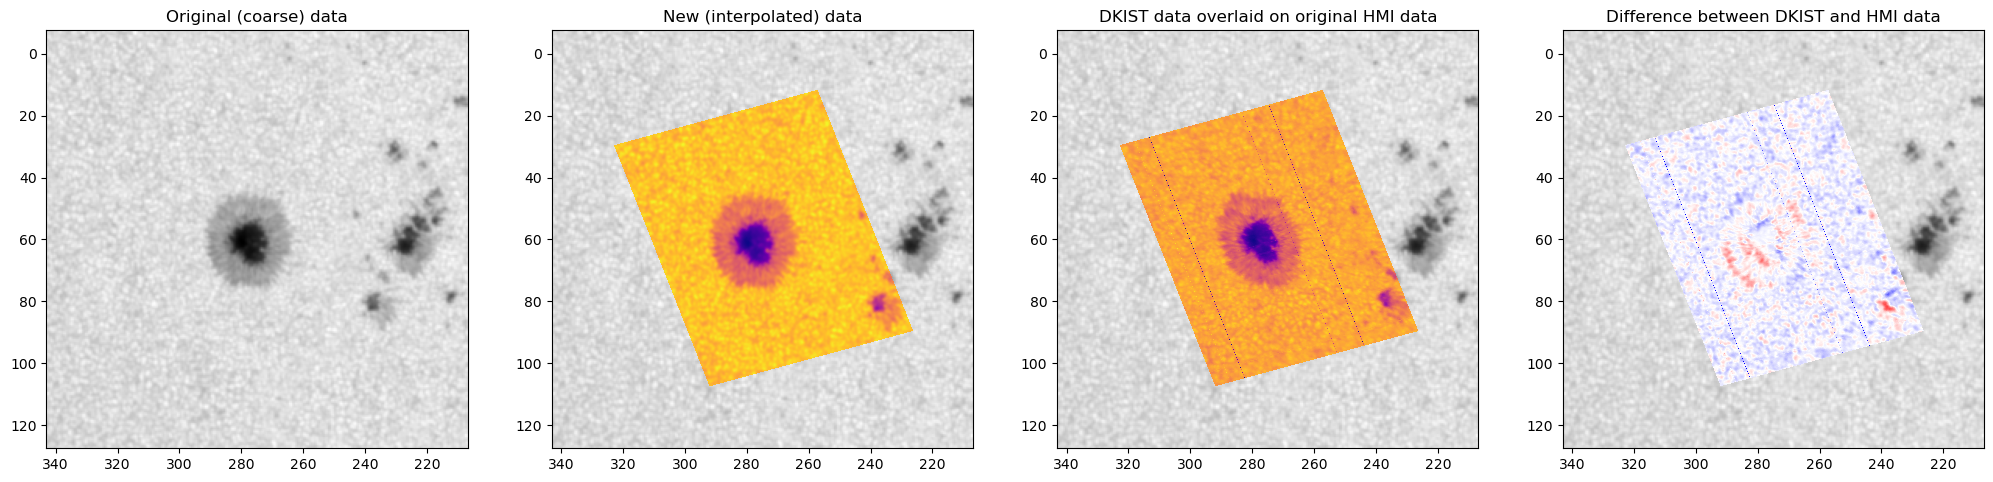

In [4]:
plt.figure(figsize = [25, 8])
plt.subplot(1,4,1)
plt.title('Original (coarse) data')
plt.imshow(relavent_hmi_data, extent = [relavent_hmix[0], relavent_hmix[-1], relavent_hmiy[0], relavent_hmiy[-1]], cmap = 'grey', origin = 'lower')

plt.subplot(1,4,2)
plt.title('New (interpolated) data')
plt.imshow(relavent_hmi_data, extent = [relavent_hmix[0], relavent_hmix[-1], relavent_hmiy[0], relavent_hmiy[-1]], cmap = 'grey', origin = 'lower')
plt.pcolormesh(coords_new[:, :, 0], coords_new[:, :, 1], Z_fine, cmap = 'plasma')

plt.subplot(1,4,3)
plt.title('DKIST data overlaid on original HMI data')
plt.imshow(relavent_hmi_data, extent = [relavent_hmix[0], relavent_hmix[-1], relavent_hmiy[0], relavent_hmiy[-1]], cmap = 'grey', origin = 'lower')
plt.pcolormesh(coords_new[:, :, 0], coords_new[:, :, 1], data_numpy, cmap = 'plasma', alpha = 1)

plt.subplot(1,4,4)
plt.title('Difference between DKIST and HMI data')
plt.imshow(relavent_hmi_data, extent = [relavent_hmix[0], relavent_hmix[-1], relavent_hmiy[0], relavent_hmiy[-1]], cmap = 'grey', origin = 'lower')
plt.pcolormesh(coords_new[:, :, 0], coords_new[:, :, 1], data_numpy - Z_fine, cmap = 'bwr', alpha = 1, vmin = -0.5, vmax = 0.5)